# Feature Scaling

Feature Scaling is an important step in preparing data for Machine Learning.

The main goal of Feature Scaling is to transform features with different numerical scales into a comparable and appropriate scale.

For example, suppose we have two features:

- Age: between 18 and 80
- Income: between 10,000 and 500,000

The large difference in their scales can cause problems for algorithms that are sensitive to the magnitude or distance between feature values.

In this section, we will learn:

- Standardization
- StandardScaler
- Min-Max Scaling
- MinMaxScaler
- fit
- transform
- fit_transform
- Data Leakage
- When Feature Scaling is necessary
- When Feature Scaling is not necessary

## Mathematical Background

To understand Feature Scaling, we first need to review some basic statistical concepts.

### Mean

The mean represents the average value of a dataset:

$$
\mu = \frac{1}{n}\sum_{i=1}^{n}x_i
$$

where:

- $x_i$ is an individual data point.
- $n$ is the number of data points.
- $\mu$ is the mean of the data.

---

### Variance

Variance measures how spread out the data is around its mean:

$$
\sigma^2 = \frac{1}{n}\sum_{i=1}^{n}(x_i-\mu)^2
$$

A larger variance means that the data points are more spread out around the mean.

---

### Standard Deviation

Standard deviation is the square root of the variance:

$$
\sigma = \sqrt{\sigma^2}
$$

Therefore:

$$
\sigma =
\sqrt{
\frac{1}{n}
\sum_{i=1}^{n}(x_i-\mu)^2
}
$$

Standard deviation tells us approximately how far the data points are spread from the mean.

---

### Example

Suppose we have:

$$
X = [10,20,30]
$$

The mean is:

$$
\mu = \frac{10+20+30}{3}=20
$$

The variance is:

$$
\sigma^2 =
\frac{(10-20)^2+(20-20)^2+(30-20)^2}{3}
$$

$$
\sigma^2 = \frac{200}{3}
$$

Therefore:

$$
\sigma \approx 8.165
$$

## Standardization

Standardization transforms each value using the mean and standard deviation of its feature.

The formula is:

$$
z = \frac{x-\mu}{\sigma}
$$

where:

- $x$ is the original value.
- $\mu$ is the mean of the feature.
- $\sigma$ is the standard deviation of the feature.
- $z$ is the standardized value.

After Standardization, the feature will typically have:

- Mean ≈ 0
- Standard Deviation ≈ 1

Important:

Standardization does **not** guarantee that all values will be between -1 and 1.

In [1]:
from sklearn.preprocessing import StandardScaler
import numpy as np
scaler = StandardScaler()
X = np.array([
    [10],
    [20],
    [30],
    [40],
    [50]
])

In [2]:
print(X)

[[10]
 [20]
 [30]
 [40]
 [50]]


this cell shows that our model learned about our data => Mean and Scale 

In [3]:
scaler.fit(X)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [4]:
print("Mean:", scaler.mean_)
print("Scale:", scaler.scale_)

Mean: [30.]
Scale: [14.14213562]


In [5]:
X_scaled = scaler.transform(X)

print(X_scaled)

[[-1.41421356]
 [-0.70710678]
 [ 0.        ]
 [ 0.70710678]
 [ 1.41421356]]


X_scaled = scaler.fit_transform(X) is equal to this 2 lines bellow 

scaler.fit(X)

X_scaled = scaler.transform(X)

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(
    X,
    test_size=0.2,
    random_state=42
)

## Data Leakage

Data Leakage occurs when information from the test data is used during the training process.

When applying Feature Scaling, the scaler must be fitted only on the training data.

The correct procedure is:

1. Split the data into training and test sets.
2. Fit the scaler only on the training data.
3. Transform the training data.
4. Transform the test data using the same scaler.

```python
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lets see the diffrence between these two in a real dataset

In [8]:
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing(as_frame=True)

X = data.data
y = data.target

In [9]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (16512, 8)
X_test: (4128, 8)


In [12]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
#scaling test with the knowledge of x train data
X_test_scaled = scaler.transform(X_test)

print("Train mean:", X_train_scaled.mean(axis=0))
print("Train std:", X_train_scaled.std(axis=0))

print("\nTest mean:", X_test_scaled.mean(axis=0))
print("Test std:", X_test_scaled.std(axis=0))

Train mean: [-6.41175313e-17 -1.67824411e-17  1.79012705e-16 -6.89371041e-16
  0.00000000e+00  1.03276560e-17  3.38574991e-15  1.77678716e-15]
Train std: [1. 1. 1. 1. 1. 1. 1. 1.]

Test mean: [-0.02647585  0.01237949 -0.01305925 -0.00011079 -0.00429306 -0.01135997
 -0.0264153   0.03137725]
Test std: [0.9879485  0.99322892 1.17051691 1.4084032  0.97965408 0.15141161
 0.99808134 0.99433356]


In [13]:
# wrong way of using scaler
leaky_scaler = StandardScaler()

X_all_scaled = leaky_scaler.fit_transform(X)

X_train_leaky = X_all_scaled[X_train.index]
X_test_leaky = X_all_scaled[X_test.index]

print("Train mean:", X_train_leaky.mean(axis=0))
print("Train std:", X_train_leaky.std(axis=0))


print("\nTest mean:", X_test_leaky.mean(axis=0))
print("Test std:", X_test_leaky.std(axis=0))

Train mean: [ 5.30760270e-03 -2.47921524e-03  2.52020736e-03  2.02557416e-05
  8.62089179e-04  2.53288532e-03  5.28479200e-03 -6.28205824e-03]
Train std: [1.00234794 1.00134006 0.96491243 0.91412112 1.00405079 1.11482946
 1.0003277  1.00105298]

Test mean: [-2.12304108e-02  9.91686097e-03 -1.00808294e-02 -8.10229666e-05
 -3.44835671e-03 -1.01315413e-02 -2.11391680e-02  2.51282329e-02]
Test std: [0.99026815 0.9945599  1.12944632 1.2874511  0.98362246 0.16879813
 0.99840842 0.99538057]


## Min-Max Scaling

Min-Max Scaling transforms the values of a feature into a fixed range, usually between 0 and 1.

The formula is:

$$
x' = \frac{x-x_{\min}}{x_{\max}-x_{\min}}
$$

where:

- $x$ is the original value.
- $x_{\min}$ is the minimum value of the feature.
- $x_{\max}$ is the maximum value of the feature.
- $x'$ is the scaled value.

After Min-Max Scaling, the minimum value becomes 0 and the maximum value becomes 1.

For example, consider:

$$
X=[10,20,30]
$$

The minimum is 10 and the maximum is 30.

Therefore:

$$
10 \rightarrow 0
$$

$$
20 \rightarrow 0.5
$$

$$
30 \rightarrow 1
$$

Unlike Standardization, Min-Max Scaling does not center the data around zero. Instead, it maps the values to a specific range.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()
#scaling test with the knowledge of x train data
X_train_minmax = minmax_scaler.fit_transform(X_train)
X_test_minmax = minmax_scaler.transform(X_test)

In [15]:
print("Train min:", X_train_minmax.min(axis=0))
print("Train max:", X_train_minmax.max(axis=0))

Train min: [0. 0. 0. 0. 0. 0. 0. 0.]
Train max: [1. 1. 1. 1. 1. 1. 1. 1.]


In [16]:
print("Test min:", X_test_minmax.min(axis=0))
print("Test max:", X_test_minmax.max(axis=0))

Test min: [ 0.          0.         -0.00030304  0.00658683  0.00014014  0.00045971
 -0.00106383  0.01593625]
Test max: [1.         1.         0.93351479 1.33317365 0.45177836 0.06637405
 0.98510638 0.97310757]


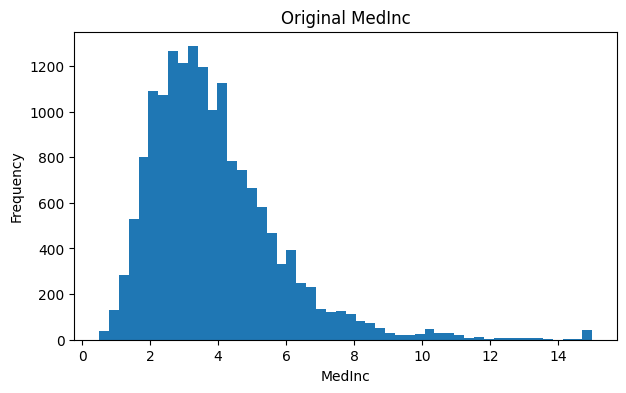

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.hist(X_train["MedInc"], bins=50)
plt.title("Original MedInc")
plt.xlabel("MedInc")
plt.ylabel("Frequency")
plt.show()

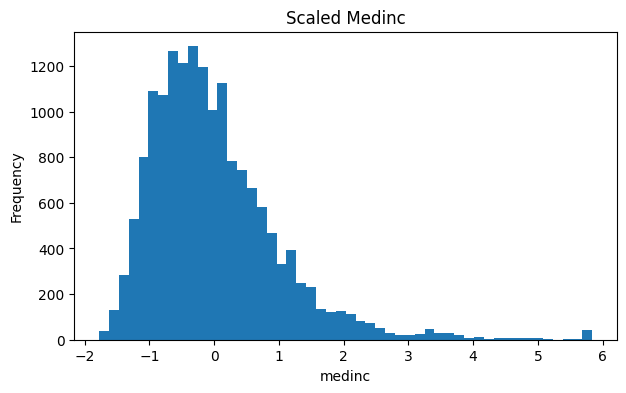

In [21]:
plt.figure(figsize =(7 , 4))
plt.hist(X_train_scaled[: , 0] , bins = 50)
plt.title("Scaled Medinc")
plt.xlabel("medinc")
plt.ylabel("Frequency")
plt.show()


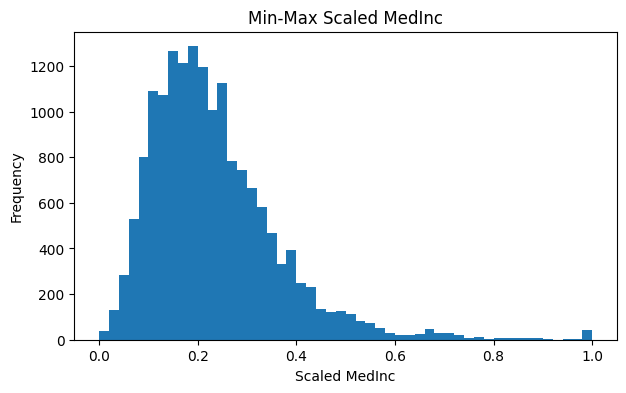

In [22]:
plt.figure(figsize=(7, 4))
plt.hist(X_train_minmax[:, 0], bins=50)
plt.title("Min-Max Scaled MedInc")
plt.xlabel("Scaled MedInc")
plt.ylabel("Frequency")
plt.show()

## StandardScaler vs MinMaxScaler

Both StandardScaler and MinMaxScaler change the scale of features without changing the relative structure of the data.

### StandardScaler

StandardScaler centers the feature around zero and scales it according to its standard deviation.

$$
z = \frac{x-\mu}{\sigma}
$$

It is often useful for algorithms that are sensitive to feature scale, such as KNN, SVM, and neural networks.

### MinMaxScaler

MinMaxScaler maps the feature to a specified range, usually [0, 1].

$$
x' = \frac{x-x_{\min}}{x_{\max}-x_{\min}}
$$

It is useful when a fixed range is desired.

### Important Note

Both methods are sensitive to outliers, but MinMaxScaler can be particularly affected because the minimum and maximum values determine the scaling range.

Feature scaling does not change the relative ordering of values. It mainly changes their numerical scale.

## Outliers and Feature Scaling

An outlier is a data point that is significantly different from the other observations.

For example:

$$
[10,11,12,13,14,100]
$$

The value 100 can be considered an outlier.

Outliers can strongly affect feature scaling.

### Effect on Min-Max Scaling

Min-Max Scaling uses the minimum and maximum values:

$$
x' = \frac{x-x_{\min}}{x_{\max}-x_{\min}}
$$

Therefore, a very large outlier can significantly increase $x_{\max}$ and compress most of the other values into a small range.

### Effect on Standardization

StandardScaler uses the mean and standard deviation:

$$
z = \frac{x-\mu}{\sigma}
$$

Outliers can also affect the mean and standard deviation.

Therefore, both StandardScaler and MinMaxScaler are sensitive to outliers.

When strong outliers are present, other approaches such as RobustScaler may be more appropriate.

## Robust Scaling, Quartiles, and Outliers

RobustScaler is another feature scaling technique that is designed to be less sensitive to outliers.

Unlike StandardScaler, which uses the mean and standard deviation, RobustScaler uses the median and the interquartile range (IQR).

The formula is:

$$
x' = \frac{x-\text{Median}(X)}{IQR(X)}
$$

where:

$$
IQR = Q_3-Q_1
$$

---

## Quartiles

Quartiles divide an ordered dataset into four parts.

The three main quartiles are:

- $Q_1$: First quartile. Approximately 25% of the observations are below this value.
- $Q_2$: Second quartile, also called the median. Approximately 50% of the observations are below this value.
- $Q_3$: Third quartile. Approximately 75% of the observations are below this value.

The Interquartile Range is defined as:

$$
IQR = Q_3-Q_1
$$

The IQR represents the spread of the middle 50% of the data.

---

## Example

Consider the following ordered dataset:

$$
[10,11,12,13,14,15,16,17,18,100]
$$

There are 10 observations.

The median is the average of the 5th and 6th values:

$$
Q_2 = \frac{14+15}{2}=14.5
$$

The lower half is:

$$
[10,11,12,13,14]
$$

Therefore:

$$
Q_1=12
$$

The upper half is:

$$
[15,16,17,18,100]
$$

Therefore:

$$
Q_3=17
$$

The IQR is:

$$
IQR=Q_3-Q_1
$$

$$
IQR=17-12=5
$$

---

## Detecting Outliers

A common method for detecting outliers uses the IQR.

The lower and upper boundaries are:

$$
Lower\ Bound = Q_1-1.5(IQR)
$$

$$
Upper\ Bound = Q_3+1.5(IQR)
$$

For our example:

$$
Lower\ Bound=12-1.5(5)=4.5
$$

and:

$$
Upper\ Bound=17+1.5(5)=24.5
$$

Therefore, values below 4.5 or above 24.5 are considered potential outliers.

In our dataset:

$$
100>24.5
$$

so 100 is an outlier.

---

## Box Plot

A box plot is a visualization commonly used to summarize the distribution of numerical data and identify potential outliers.

The box represents the range from $Q_1$ to $Q_3$.

The line inside the box represents the median.

The distance between $Q_1$ and $Q_3$ is the IQR.

Values outside the lower and upper boundaries are typically displayed as individual points and can indicate potential outliers.

The main components are:

- $Q_1$: Lower edge of the box
- Median: Line inside the box
- $Q_3$: Upper edge of the box
- IQR: Size of the box
- Whiskers: Extend toward the non-outlier observations
- Points outside the whiskers: Potential outliers

---

## Why Does RobustScaler Use Median and IQR?

Mean and standard deviation can be strongly affected by extreme values.

For example, consider:

$$
[10,11,12,13,14,100]
$$

The value 100 can significantly affect the mean and standard deviation.

The median and IQR are more resistant to extreme observations.

Therefore, RobustScaler uses:

$$
\text{Median}
$$

and:

$$
IQR
$$

instead of:

$$
\text{Mean}
$$

and:

$$
\text{Standard Deviation}
$$

This makes RobustScaler more robust when strong outliers are present.

---

## RobustScaler in Scikit-learn

```python
from sklearn.preprocessing import RobustScaler

robust_scaler = RobustScaler()

X_train_robust = robust_scaler.fit_transform(X_train)
X_test_robust = robust_scaler.transform(X_test)

In [26]:
from sklearn.preprocessing import RobustScaler
#from sklearn.preprocessing import robust_scale => wrong import

robust_scaler = RobustScaler()

X_train_robust = robust_scaler.fit_transform(X_train)
X_test_robust = robust_scaler.transform(X_test)

In [27]:
import numpy as np

X_outlier = np.array([
    [10],
    [11],
    [12],
    [13],
    [14],
    [100]
])

In [28]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

standard = StandardScaler()
minmax = MinMaxScaler()
robust = RobustScaler()

X_standard = standard.fit_transform(X_outlier)
X_minmax = minmax.fit_transform(X_outlier)
X_robust = robust.fit_transform(X_outlier)

print("Original:")
print(X_outlier.ravel())

print("\nStandardScaler:")
print(X_standard.ravel())

print("\nMinMaxScaler:")
print(X_minmax.ravel())

print("\nRobustScaler:")
print(X_robust.ravel())

Original:
[ 10  11  12  13  14 100]

StandardScaler:
[-0.50780398 -0.47733574 -0.4468675  -0.41639926 -0.38593102  2.2343375 ]

MinMaxScaler:
[0.         0.01111111 0.02222222 0.03333333 0.04444444 1.        ]

RobustScaler:
[-1.  -0.6 -0.2  0.2  0.6 35. ]


In [30]:
feature = X_train[["MedInc"]]

standard_result = StandardScaler().fit_transform(feature)
minmax_result = MinMaxScaler().fit_transform(feature)
robust_result = RobustScaler().fit_transform(feature)

print("Original:")
print(feature.describe())

print("\nStandardScaler:")
print(
    "min =", standard_result.min(),
    "max =", standard_result.max(),
    "mean =", standard_result.mean(),
    "std =", standard_result.std()
)

print("\nMinMaxScaler:")
print(
    "min =", minmax_result.min(),
    "max =", minmax_result.max(),
    "mean =", minmax_result.mean(),
    "std =", minmax_result.std()
)

print("\nRobustScaler:")
print(
    "min =", robust_result.min(),
    "max =", robust_result.max(),
    "median =", np.median(robust_result),
    "IQR =", np.percentile(robust_result, 75) - np.percentile(robust_result, 25)
)

Original:
             MedInc
count  16512.000000
mean       3.880754
std        1.904294
min        0.499900
25%        2.566700
50%        3.545800
75%        4.773175
max       15.000100

StandardScaler:
min = -1.7754384434994495 max = 5.839267946533966 mean = -6.411753126711176e-17 std = 0.9999999999999999

MinMaxScaler:
min = 0.0 max = 1.0 mean = 0.23315914659864626 std = 0.13132482708839044

RobustScaler:
min = -1.3804371225597387 max = 5.1912212918795815 median = 1.0064106666096695e-16 IQR = 1.0
